# ── ETAPA 3 – Aplicação de Algoritmos de Clusterização ──
### Tema 8: Finanças Pessoais e Pix · Detecção de Anomalias

> **Objetivo:** Separar transações em **2 grupos** (Normal × Anomalia) via clusterização não-supervisionada,  
> avaliando coesão/separação e testando estabilidade dos modelos.

---


## 1. Importações

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.metrics import (
    silhouette_score, davies_bouldin_score, calinski_harabasz_score,
    adjusted_rand_score, normalized_mutual_info_score,
    confusion_matrix, classification_report
)
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics.pairwise import euclidean_distances, manhattan_distances, cosine_distances
from sklearn.neighbors import NearestNeighbors
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.spatial.distance import cdist

plt.rcParams['figure.figsize']  = (10, 5)
plt.rcParams['axes.spines.top']  = False
plt.rcParams['axes.spines.right']= False
CORES = {'normal': '#4C9BE8', 'anomalia': '#E84C4C', 'neutra': '#5DBE7E'}

print("✅ Bibliotecas carregadas com sucesso!")

✅ Bibliotecas carregadas com sucesso!


## 2. Recarregamento e Pré-Processamento (retomando Etapas 1 e 2)
Reproduzimos o pipeline das etapas anteriores:  
- Leitura do CSV com separador `;`  
- Conversão e limpeza de datas inválidas  
- Criação das variáveis temporais

In [2]:
# ── Leitura da base bruta ─────────────────────────────────────────────────────
df_raw = pd.read_csv('comprovantes_pix_10000_anomalias.csv', sep=';')

# ── Etapa 1: limpeza e variáveis temporais ───────────────────────────────────
df_raw['DataHora']        = pd.to_datetime(df_raw['DataHora'], errors='coerce')
df_raw                    = df_raw.dropna(subset=['DataHora']).copy()
df_raw['Hora_Transacao']  = df_raw['DataHora'].dt.hour
df_raw['Dia_Semana']      = df_raw['DataHora'].dt.dayofweek
df_raw['Fim_de_Semana']   = (df_raw['Dia_Semana'] >= 5).astype(int)
df_raw['Horario_Comercial']= df_raw['Hora_Transacao'].between(8, 18).astype(int)

y_true = df_raw['Anomalia'].values

print(f"Registros após limpeza : {len(df_raw):,}")
print(f"Anomalias presentes    : {y_true.sum():,}  ({y_true.mean()*100:.2f}%)")
print(f"Colunas disponíveis    : {df_raw.columns.tolist()}")

Registros após limpeza : 9,976
Anomalias presentes    : 76  (0.76%)
Colunas disponíveis    : ['EndToEndId', 'DataHora', 'Valor', 'Moeda', 'Pagador_Nome', 'Pagador_CPF_CNPJ', 'Pagador_Banco', 'Recebedor_Nome', 'Recebedor_CPF_CNPJ', 'Recebedor_Banco', 'ChavePix_Utilizada', 'TipoChave', 'Descricao', 'Status', 'Anomalia', 'Hora_Transacao', 'Dia_Semana', 'Fim_de_Semana', 'Horario_Comercial']


## 3. Engenharia de Variáveis (Feature Engineering)
Como a base possui **maioria de variáveis categóricas** e apenas uma numérica (`Valor`),  
a engenharia de features é o principal vetor de enriquecimento dos dados para clusterização.

| Feature criada | Raciocínio |
|---|---|
| `Banco_Fantasma` | Flag para o recebedor "Banco Fantasma S.A." – encontrado na EDA como forte indicador |
| `Horario_Madrugada` | Transações entre 0h–5h são atípicas para Pix legítimos |
| `Mesmo_Banco` | Autotransferências têm padrão diferente de transferências externas |
| `Valor_Log` | Log-transform reduz a assimetria positiva do Valor |
| `Valor_Percentil` | Posição relativa do valor na distribuição (0–1) |
| `Chave_Anonima` | Chaves Aleatória e Telefone são mais difíceis de rastrear |
| `Status_Pendente` | Status pendente pode indicar transação problemática |
| `Status_Estornada` | Status de estorno pode indicar transação contestada |
| `Score_Suspeita` | Score composto: soma ponderada dos sinais de risco |

In [3]:
df = df_raw.copy()

# ── Flags binárias de risco ───────────────────────────────────────────────────
df['Banco_Fantasma']   = (df['Recebedor_Banco'] == 'Banco Fantasma S.A.').astype(int)
df['Horario_Madrugada']= df['Hora_Transacao'].between(0, 5).astype(int)
df['Mesmo_Banco']      = (df['Pagador_Banco'] == df['Recebedor_Banco']).astype(int)
df['Chave_Anonima']    = df['TipoChave'].isin(['Chave Aleatória', 'Telefone']).astype(int)
df['Status_Pendente']  = (df['Status'] == 'Pendente').astype(int)
df['Status_Estornada'] = (df['Status'] == 'Estornada').astype(int)

# ── Transformações numéricas ──────────────────────────────────────────────────
df['Valor_Log']       = np.log1p(df['Valor'])
df['Valor_Percentil'] = df['Valor'].rank(pct=True)

# ── Score composto (Banco_Fantasma recebe peso 3 por ser o sinal mais forte) ──
df['Score_Suspeita'] = (
    df['Banco_Fantasma']    * 3 +
    df['Horario_Madrugada'] * 1 +
    df['Chave_Anonima']     * 1 +
    df['Status_Pendente']   * 1
)

# ── Encoding de categóricas ───────────────────────────────────────────────────
le = LabelEncoder()
df['TipoChave_enc']       = le.fit_transform(df['TipoChave'])
df['Pagador_Banco_enc']   = le.fit_transform(df['Pagador_Banco'])
df['Recebedor_Banco_enc'] = le.fit_transform(df['Recebedor_Banco'])
df['Status_enc']          = le.fit_transform(df['Status'])

# ── Verificação: Score por grupo ──────────────────────────────────────────────
print("Score_Suspeita por grupo (Anomalia real):")
print(df.groupby('Anomalia')['Score_Suspeita'].describe().round(3))
print()
print("Banco_Fantasma × Anomalia:")
print(pd.crosstab(df['Banco_Fantasma'], df['Anomalia'],
                  rownames=['Banco Fantasma'], colnames=['Anomalia']))

Score_Suspeita por grupo (Anomalia real):
           count   mean    std  min   25%  50%  75%  max
Anomalia                                                
0         9900.0  0.984  0.810  0.0  0.00  1.0  2.0  3.0
1           76.0  1.842  1.705  0.0  0.75  1.0  3.0  6.0

Banco_Fantasma × Anomalia:
Anomalia           0   1
Banco Fantasma          
0               9900  56
1                  0  20


## 4. Seleção e Normalização das Features

In [4]:
FEATURES = [
    'Valor',               # valor bruto da transação
    'Valor_Log',           # log-transform do valor
    'Valor_Percentil',     # posição percentual do valor
    'Hora_Transacao',      # hora (0–23)
    'Dia_Semana',          # dia da semana (0=seg … 6=dom)
    'Fim_de_Semana',       # flag binária
    'Horario_Comercial',   # flag binária (8h–18h)
    'Horario_Madrugada',   # flag binária (0h–5h)
    'TipoChave_enc',       # tipo de chave Pix (encoded)
    'Status_enc',          # status (encoded)
    'Pagador_Banco_enc',   # banco do pagador (encoded)
    'Recebedor_Banco_enc', # banco do recebedor (encoded) — captura Banco Fantasma
    'Banco_Fantasma',      # flag explícita para Banco Fantasma
    'Mesmo_Banco',         # flag: mesmo banco para remetente e destinatário
    'Chave_Anonima',       # flag: chave anônima utilizada
    'Status_Pendente',     # flag: status pendente
    'Status_Estornada',    # flag: status estornada
    'Score_Suspeita',      # score composto de risco
]

X_raw = df[FEATURES].values

# ── StandardScaler: média=0, desvio=1 ────────────────────────────────────────
scaler_std = StandardScaler()
X_std = scaler_std.fit_transform(X_raw)

# ── MinMaxScaler: escala [0,1] ────────────────────────────────────────────────
scaler_mm = MinMaxScaler()
X_mm = scaler_mm.fit_transform(X_raw)

print(f"Dimensão do conjunto: {X_std.shape}")
print(f"  StandardScaler → média: {X_std.mean():.4f} | dp: {X_std.std():.4f}")
print(f"  MinMaxScaler   → min: {X_mm.min():.4f}    | max: {X_mm.max():.4f}")
print()
print("Features utilizadas:")
for i, f in enumerate(FEATURES, 1):
    print(f"  {i:2d}. {f}")

Dimensão do conjunto: (9976, 18)
  StandardScaler → média: -0.0000 | dp: 1.0000
  MinMaxScaler   → min: 0.0000    | max: 1.0000

Features utilizadas:
   1. Valor
   2. Valor_Log
   3. Valor_Percentil
   4. Hora_Transacao
   5. Dia_Semana
   6. Fim_de_Semana
   7. Horario_Comercial
   8. Horario_Madrugada
   9. TipoChave_enc
  10. Status_enc
  11. Pagador_Banco_enc
  12. Recebedor_Banco_enc
  13. Banco_Fantasma
  14. Mesmo_Banco
  15. Chave_Anonima
  16. Status_Pendente
  17. Status_Estornada
  18. Score_Suspeita


## 5. Análise das Métricas de Distância
Comparamos **Euclidiana**, **Manhattan** e **Cosine** calculando distâncias médias  
intra-grupo e inter-grupo usando os rótulos verdadeiros apenas para fins analíticos.

- **Distância intra-grupo** = coesão interna (quanto menor, mais compacto o cluster)  
- **Distância inter-grupo** = separação (quanto maior, mais distintos os grupos)  
- **Razão sep/coesão** = métrica de qualidade — quanto maior, melhor a separação

Análise de Distâncias – Coesão e Separação
            Intra Normal  Intra Anomalia  Inter (sep.)  Razão sep/coesão
Euclidiana        5.6004         13.5648       11.3604            1.1855
Manhattan        17.0915         29.7358       26.0024            1.1106
Cosine            0.9939          0.8741        1.0045            1.0755



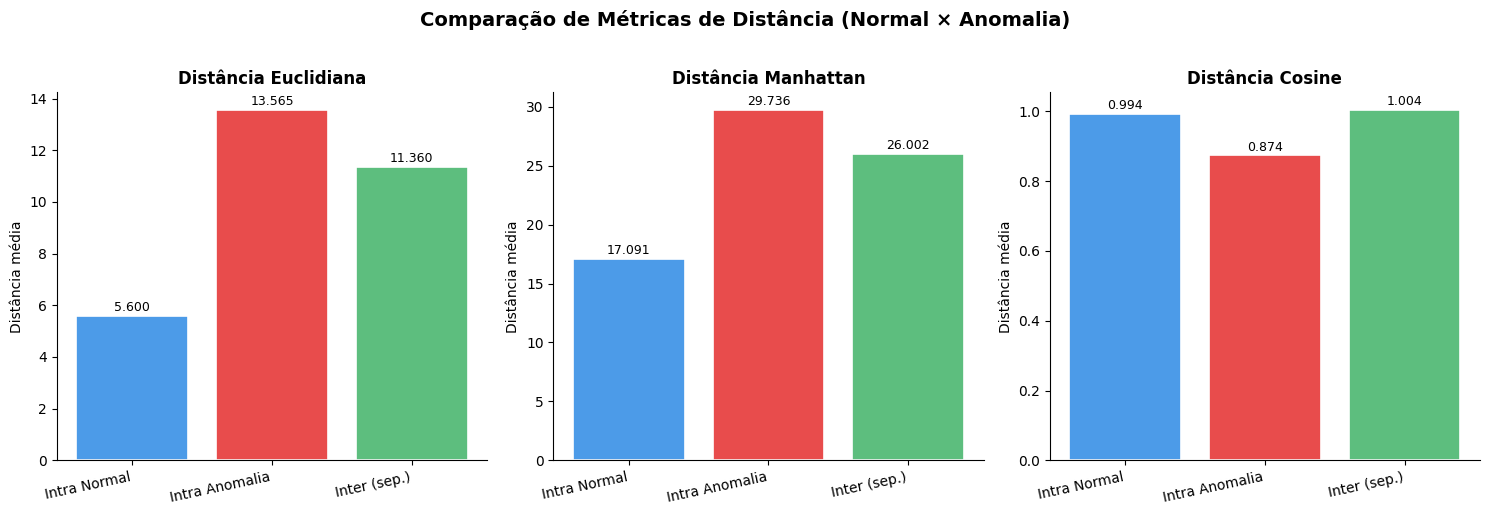

💡 Melhor razão sep/coesão: Euclidiana (1.1855)


In [5]:
# Amostras para cálculo
rng = np.random.default_rng(42)
idx_n = rng.choice(np.where(y_true==0)[0], size=300, replace=False)
idx_a = np.where(y_true == 1)[0]   # todos os anômalos

X_n, X_a = X_std[idx_n], X_std[idx_a]

metricas_dist = {}
for nome, fn in [('Euclidiana', euclidean_distances),
                 ('Manhattan',  manhattan_distances),
                 ('Cosine',     cosine_distances)]:
    d_nn = fn(X_n, X_n).mean()
    d_aa = fn(X_a, X_a).mean()
    d_na = fn(X_n, X_a).mean()
    razao = d_na / ((d_nn + d_aa) / 2)
    metricas_dist[nome] = {
        'Intra Normal':  round(d_nn, 4),
        'Intra Anomalia':round(d_aa, 4),
        'Inter (sep.)':  round(d_na, 4),
        'Razão sep/coesão': round(razao, 4)
    }

df_dist = pd.DataFrame(metricas_dist).T
print("Análise de Distâncias – Coesão e Separação")
print("=" * 55)
print(df_dist.to_string())
print()

# Gráfico comparativo
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
cats  = ['Intra Normal', 'Intra Anomalia', 'Inter (sep.)']
clrs  = [CORES['normal'], CORES['anomalia'], CORES['neutra']]

for ax, metrica in zip(axes, metricas_dist.keys()):
    vals = [metricas_dist[metrica][c] for c in cats]
    bars = ax.bar(cats, vals, color=clrs, edgecolor='white', linewidth=1.2)
    ax.set_title(f'Distância {metrica}', fontweight='bold', fontsize=12)
    ax.set_ylabel('Distância média')
    ax.set_xticklabels(cats, rotation=12, ha='right')
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005 * max(vals),
                f'{val:.3f}', ha='center', va='bottom', fontsize=9)

plt.suptitle('Comparação de Métricas de Distância (Normal × Anomalia)',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

best_m = max(metricas_dist, key=lambda k: metricas_dist[k]['Razão sep/coesão'])
print(f"💡 Melhor razão sep/coesão: {best_m} ({metricas_dist[best_m]['Razão sep/coesão']:.4f})")

## 6. Determinação do K Ótimo (Elbow + Silhouette + DB + CH)
Embora o problema indique **k=2** (Normal vs Anomalia), verificamos formalmente  
se os dados corroboram esta escolha usando quatro critérios distintos.

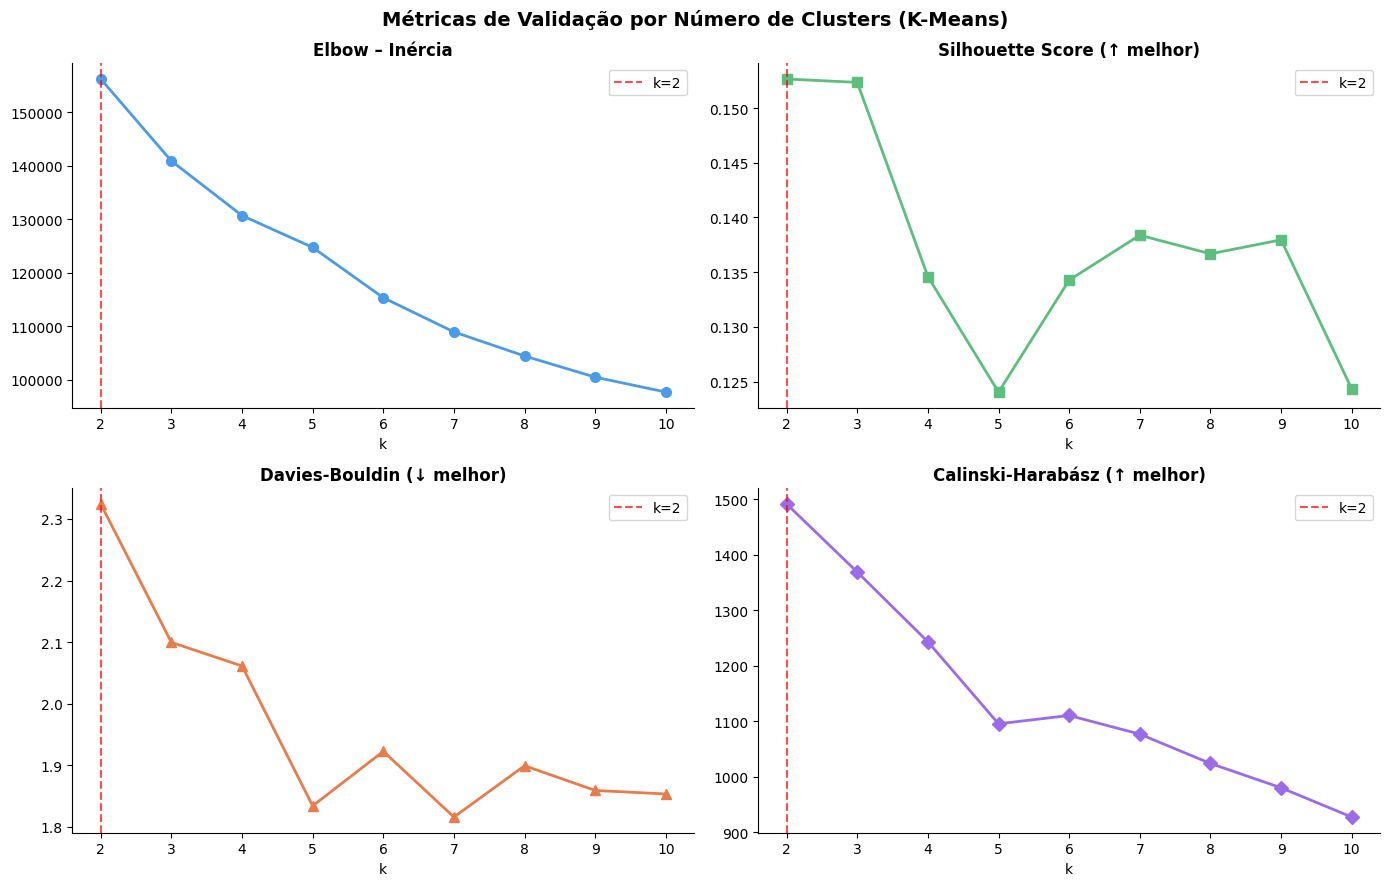

k=2 → Silhouette: 0.1526 | DB: 2.3243 | CH: 1491.0
k=3 → Silhouette: 0.1523 | DB: 2.0995 | CH: 1368.5


In [6]:
ks, inertias, sil_k, db_k, ch_k = range(2, 11), [], [], [], []

for k in ks:
    km    = KMeans(n_clusters=k, n_init=15, random_state=42)
    lbl   = km.fit_predict(X_std)
    inertias.append(km.inertia_)
    sil_k.append(silhouette_score(X_std, lbl))
    db_k.append(davies_bouldin_score(X_std, lbl))
    ch_k.append(calinski_harabasz_score(X_std, lbl))

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
ks_list = list(ks)

configs = [
    (axes[0,0], inertias, 'Elbow – Inércia',                 'o-', '#4C9BE8', False),
    (axes[0,1], sil_k,    'Silhouette Score (↑ melhor)',      's-', '#5DBE7E', True),
    (axes[1,0], db_k,     'Davies-Bouldin (↓ melhor)',        '^-', '#E87C4C', False),
    (axes[1,1], ch_k,     'Calinski-Harabász (↑ melhor)',     'D-', '#9B6BE8', True),
]
for ax, vals, titulo, fmt, cor, _ in configs:
    ax.plot(ks_list, vals, fmt, color=cor, linewidth=2, markersize=7)
    ax.axvline(x=2, color='red', linestyle='--', alpha=0.7, label='k=2')
    ax.set_title(titulo, fontweight='bold'); ax.set_xlabel('k'); ax.legend()

plt.suptitle('Métricas de Validação por Número de Clusters (K-Means)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"k=2 → Silhouette: {sil_k[0]:.4f} | DB: {db_k[0]:.4f} | CH: {ch_k[0]:.1f}")
print(f"k=3 → Silhouette: {sil_k[1]:.4f} | DB: {db_k[1]:.4f} | CH: {ch_k[1]:.1f}")

## 7. K-Means com Distâncias Euclidiana e Manhattan (k=2)
O K-Means nativo do scikit-learn usa distância Euclidiana.  
Para Manhattan implementamos uma versão custom via `cdist`.

In [7]:
def alinhar_labels(labels, y_ref):
    """Garante que cluster 0 = grupo majoritário (Normal)."""
    lbl = labels.copy()
    if lbl.mean() > 0.5:
        lbl = 1 - lbl
    return lbl

def metricas_cluster(X, labels, y_ref, nome):
    sil = silhouette_score(X, labels)
    db  = davies_bouldin_score(X, labels)
    ch  = calinski_harabasz_score(X, labels)
    ari = adjusted_rand_score(y_ref, labels)
    nmi = normalized_mutual_info_score(y_ref, labels)
    return {'Algoritmo': nome,
            'Silhouette':        round(sil, 4),
            'Davies-Bouldin':    round(db,  4),
            'Calinski-Harabász': round(ch,  2),
            'ARI':               round(ari, 4),
            'NMI':               round(nmi, 4)}

# ── K-Means Euclidiana ────────────────────────────────────────────────────────
km_eucl      = KMeans(n_clusters=2, n_init=20, random_state=42)
labels_eucl  = alinhar_labels(km_eucl.fit_predict(X_std), y_true)

# ── K-Means Manhattan (implementação custom) ──────────────────────────────────
def kmeans_manhattan(X, k=2, n_init=15, max_iter=300, seed=42):
    best_labels, best_inertia = None, np.inf
    rng = np.random.default_rng(seed)
    for _ in range(n_init):
        idx     = rng.choice(len(X), size=k, replace=False)
        centers = X[idx].copy()
        for __ in range(max_iter):
            D      = cdist(X, centers, metric='cityblock')
            labels = D.argmin(axis=1)
            new_c  = np.array([X[labels==j].mean(axis=0)
                                if (labels==j).any() else centers[j]
                                for j in range(k)])
            if np.allclose(new_c, centers): break
            centers = new_c
        inertia = cdist(X, centers, metric='cityblock')[np.arange(len(X)), labels].sum()
        if inertia < best_inertia:
            best_labels, best_inertia = labels.copy(), inertia
    return best_labels

labels_manh = alinhar_labels(kmeans_manhattan(X_std, k=2, seed=42), y_true)

# ── Resultados ────────────────────────────────────────────────────────────────
resultados = []
resultados.append(metricas_cluster(X_std, labels_eucl, y_true, 'K-Means Euclidiana'))
resultados.append(metricas_cluster(X_std, labels_manh, y_true, 'K-Means Manhattan'))

for nome, labels in [('Euclidiana', labels_eucl), ('Manhattan', labels_manh)]:
    cm = confusion_matrix(y_true, labels)
    print(f"Matriz de Confusão – K-Means {nome}:")
    print(pd.DataFrame(cm,
          index=['Real Normal','Real Anomalia'],
          columns=['Pred Normal','Pred Anomalia']))
    print()

print("💡 Nota: O K-Means tem alta ESTABILIDADE (ARI entre seeds = 1.0),")
print("   porém baixo ARI vs ground truth pois divide os dados por")
print("   geometria de centróides — não por densidade de anomalias.")

Matriz de Confusão – K-Means Euclidiana:
               Pred Normal  Pred Anomalia
Real Normal           6633           3267
Real Anomalia           39             37

Matriz de Confusão – K-Means Manhattan:
               Pred Normal  Pred Anomalia
Real Normal           6633           3267
Real Anomalia           51             25

💡 Nota: O K-Means tem alta ESTABILIDADE (ARI entre seeds = 1.0),
   porém baixo ARI vs ground truth pois divide os dados por
   geometria de centróides — não por densidade de anomalias.


## 8. Clustering Hierárquico com Distância Cosine
A distância Cosine mede o **ângulo** entre vetores, sendo menos sensível à magnitude.  
É útil aqui porque o `Score_Suspeita` cria vetores com magnitudes muito distintas  
entre transações normais (score baixo) e anômalas (score alto).

In [8]:
# Agglomerative + Cosine (average linkage suporta cosine no scikit-learn)
agg_cos      = AgglomerativeClustering(n_clusters=2, metric='cosine', linkage='average')
labels_cos   = alinhar_labels(agg_cos.fit_predict(X_mm), y_true)   # MinMax estável para cosine

resultados.append(metricas_cluster(X_mm, labels_cos, y_true, 'Agglomerative Cosine'))

cm_cos = confusion_matrix(y_true, labels_cos)
print("Matriz de Confusão – Agglomerative Cosine:")
print(pd.DataFrame(cm_cos,
      index=['Real Normal','Real Anomalia'],
      columns=['Pred Normal','Pred Anomalia']))
print()
print(f"Cluster 0 (Normal)  : {(labels_cos==0).sum():,}")
print(f"Cluster 1 (Anomalia): {(labels_cos==1).sum():,}")

Matriz de Confusão – Agglomerative Cosine:
               Pred Normal  Pred Anomalia
Real Normal           9900              0
Real Anomalia           74              2

Cluster 0 (Normal)  : 9,974
Cluster 1 (Anomalia): 2


## 9. DBSCAN – Detecção de Anomalias por Densidade
O DBSCAN é o algoritmo mais natural para detecção de anomalias:  
pontos que **não pertencem a nenhuma região densa** recebem rótulo `-1` (ruído),  
mapeados diretamente como **Anomalia**.

> **Estratégia de otimização:** usamos dois critérios simultâneos:  
> - `Silhouette` para qualidade estrutural dos clusters  
> - `ARI` vs ground truth para qualidade da detecção de anomalias

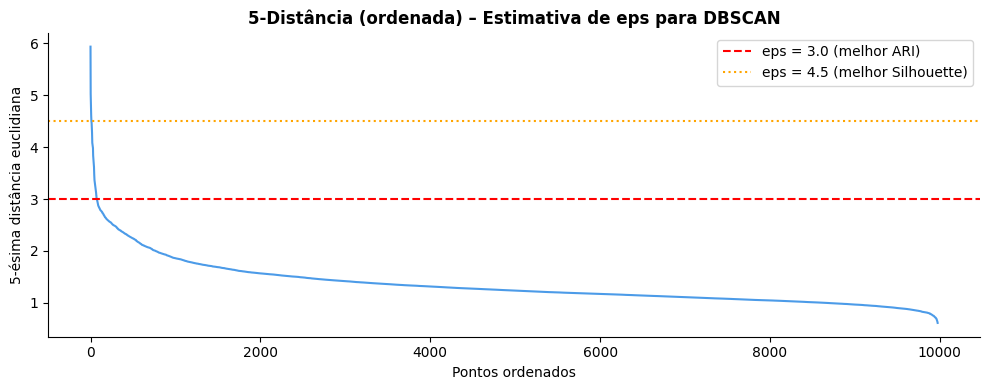

In [9]:
# ── Gráfico k-distância para estimar eps ─────────────────────────────────────
k_nn  = 5
nbrs  = NearestNeighbors(n_neighbors=k_nn, metric='euclidean').fit(X_std)
dists, _ = nbrs.kneighbors(X_std)
dist_sorted = np.sort(dists[:, k_nn-1])[::-1]

plt.figure(figsize=(10, 4))
plt.plot(dist_sorted, color=CORES['normal'], linewidth=1.5)
plt.axhline(y=3.0, color='red',    linestyle='--', label='eps = 3.0 (melhor ARI)')
plt.axhline(y=4.5, color='orange', linestyle=':', label='eps = 4.5 (melhor Silhouette)')
plt.title(f'{k_nn}-Distância (ordenada) – Estimativa de eps para DBSCAN', fontweight='bold')
plt.xlabel('Pontos ordenados'); plt.ylabel(f'{k_nn}-ésima distância euclidiana')
plt.legend(); plt.tight_layout(); plt.show()

In [10]:
# ── Grid search DBSCAN (duplo critério: Silhouette + ARI) ────────────────────
resultados_dbscan = []

for eps in [2.0, 2.5, 3.0, 3.5, 4.0, 4.5]:
    for min_s in [5, 10, 15, 20, 30]:
        db     = DBSCAN(eps=eps, min_samples=min_s, metric='euclidean')
        lbl_db = db.fit_predict(X_std)
        n_cl   = len(set(lbl_db)) - (1 if -1 in lbl_db else 0)
        noise  = (lbl_db == -1).mean() * 100
        if noise > 30 or n_cl < 1:
            continue
        lbl_bin = np.where(lbl_db == -1, 1, 0)   # ruído = Anomalia
        try:
            sil = silhouette_score(X_std, lbl_db if n_cl > 1 else lbl_bin)
            ari = adjusted_rand_score(y_true, lbl_bin)
            resultados_dbscan.append({
                'eps': eps, 'min_samples': min_s,
                'n_clusters': n_cl, 'noise_pct': round(noise, 2),
                'Silhouette': round(sil, 4), 'ARI': round(ari, 4),
                'labels': lbl_db.copy()
            })
        except:
            pass

df_dbscan = pd.DataFrame([{k: v for k, v in r.items() if k != 'labels'}
                           for r in resultados_dbscan])

print("Top 10 configurações DBSCAN (por ARI):")
print(df_dbscan.sort_values('ARI', ascending=False).head(10).to_string(index=False))

Top 10 configurações DBSCAN (por ARI):
 eps  min_samples  n_clusters  noise_pct  Silhouette    ARI
 3.0            5           4       0.51      0.1560 0.6565
 3.0           10           4       0.54      0.1558 0.6409
 3.5           15           2       0.40      0.1666 0.6159
 3.5           20           2       0.42      0.1662 0.6052
 3.5           10           2       0.35      0.1671 0.5899
 3.5           30           2       0.53      0.1647 0.5834
 3.5            5           2       0.30      0.1674 0.5426
 3.0           15           4       0.79      0.1539 0.5345
 4.0           30           1       0.29      0.7001 0.5287
 4.0           20           1       0.27      0.7110 0.5003


In [11]:
# ── Configuração escolhida: melhor ARI (objetivo = detectar anomalias) ────────
best_row_ari = df_dbscan.sort_values('ARI', ascending=False).iloc[0]
best_eps_ari = best_row_ari['eps']
best_min_ari = int(best_row_ari['min_samples'])

db_best      = DBSCAN(eps=best_eps_ari, min_samples=best_min_ari)
lbl_db_best  = db_best.fit_predict(X_std)
labels_dbscan= alinhar_labels(np.where(lbl_db_best == -1, 1, 0), y_true)

print(f"Melhor DBSCAN (ARI): eps={best_eps_ari}, min_samples={best_min_ari}")
print(f"  ARI:        {best_row_ari['ARI']:.4f}")
print(f"  Silhouette: {best_row_ari['Silhouette']:.4f}")
print(f"  Ruído (-1): {(lbl_db_best==-1).sum()} pontos ({(lbl_db_best==-1).mean()*100:.1f}%)")
print(f"  Clusters:   {len(set(lbl_db_best))-(1 if -1 in lbl_db_best else 0)}")
print()

cm_db = confusion_matrix(y_true, labels_dbscan)
print("Matriz de Confusão – DBSCAN:")
print(pd.DataFrame(cm_db,
      index=['Real Normal','Real Anomalia'],
      columns=['Pred Normal','Pred Anomalia']))

# Avalia com labels binários (Normal=0, Anomalia=1)
resultados.append(metricas_cluster(X_std, labels_dbscan, y_true, 'DBSCAN'))

Melhor DBSCAN (ARI): eps=3.0, min_samples=5
  ARI:        0.6565
  Silhouette: 0.1560
  Ruído (-1): 51 pontos (0.5%)
  Clusters:   4

Matriz de Confusão – DBSCAN:
               Pred Normal  Pred Anomalia
Real Normal           9891              9
Real Anomalia           34             42


## 10. Clustering Hierárquico Aglomerativo (Euclidiana e Manhattan)

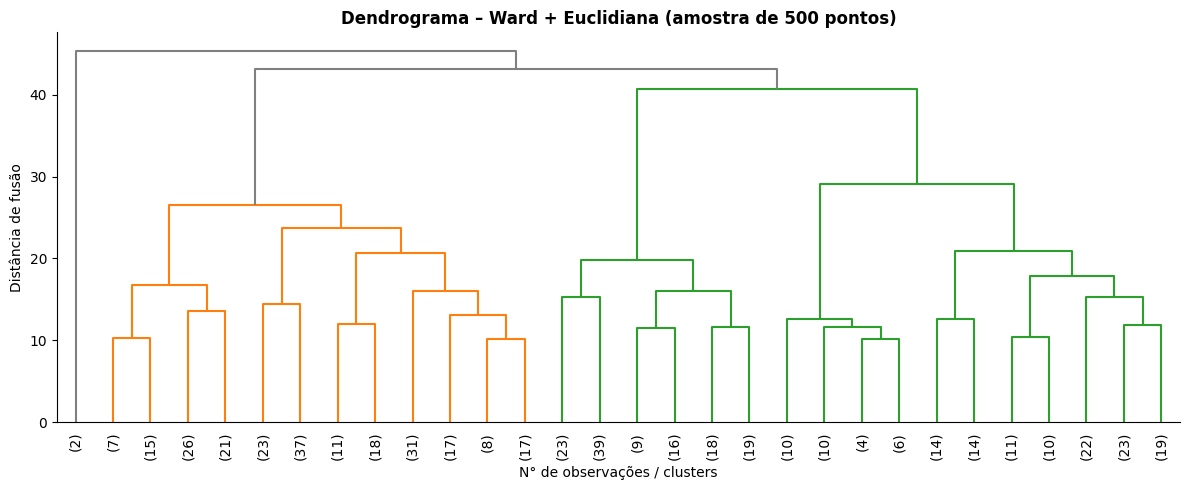

In [12]:
# ── Dendrograma – Ward + Euclidiana (amostra 500 pts) ────────────────────────
smp  = np.random.default_rng(42).choice(len(X_std), 500, replace=False)
Z    = linkage(X_std[smp], method='ward', metric='euclidean')

plt.figure(figsize=(12, 5))
dendrogram(Z, truncate_mode='lastp', p=30, leaf_rotation=90,
           color_threshold=Z[-2, 2], above_threshold_color='gray')
plt.title('Dendrograma – Ward + Euclidiana (amostra de 500 pontos)', fontweight='bold')
plt.xlabel('N° de observações / clusters'); plt.ylabel('Distância de fusão')
plt.tight_layout(); plt.show()

In [13]:
# ── Agglomerative Ward + Euclidiana ──────────────────────────────────────────
agg_ward   = AgglomerativeClustering(n_clusters=2, metric='euclidean', linkage='ward')
labels_ward= alinhar_labels(agg_ward.fit_predict(X_std), y_true)

# ── Agglomerative Average + Manhattan ─────────────────────────────────────────
agg_manh   = AgglomerativeClustering(n_clusters=2, metric='manhattan', linkage='average')
labels_manh_agg = alinhar_labels(agg_manh.fit_predict(X_std), y_true)

resultados.append(metricas_cluster(X_std, labels_ward,     y_true, 'Agglomerative Ward+Eucl.'))
resultados.append(metricas_cluster(X_std, labels_manh_agg, y_true, 'Agglomerative Avg+Manh.'))

for nome, labels in [('Ward + Euclidiana', labels_ward),
                     ('Average + Manhattan', labels_manh_agg)]:
    cm = confusion_matrix(y_true, labels)
    print(f"Agglomerative {nome}:")
    print(pd.DataFrame(cm,
          index=['Real Normal','Real Anomalia'],
          columns=['Pred Normal','Pred Anomalia']))
    print()

Agglomerative Ward + Euclidiana:
               Pred Normal  Pred Anomalia
Real Normal           7641           2259
Real Anomalia           47             29

Agglomerative Average + Manhattan:
               Pred Normal  Pred Anomalia
Real Normal           9900              0
Real Anomalia           56             20



## 11. Teste de Estabilidade – K-Means com Múltiplas Seeds
Rodamos K-Means com 5 sementes diferentes e calculamos **ARI** e **NMI** entre  
todos os pares de execuções.

> Referência técnica: **ARI > 0.8** entre pares → clusters estáveis e reprodutíveis.

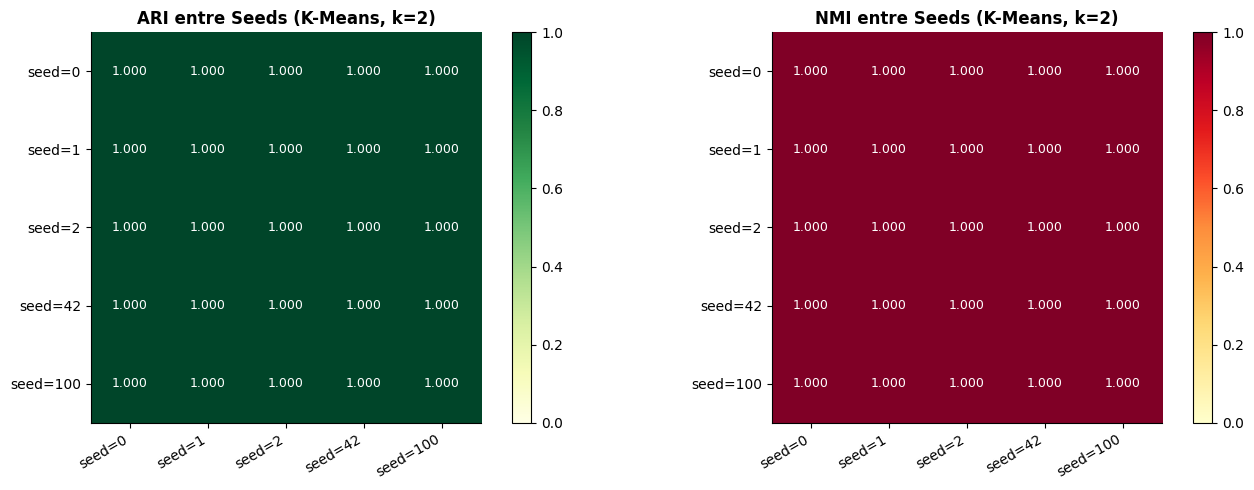

ARI médio entre pares: 1.0000 ± 0.0000
NMI médio entre pares: 1.0000 ± 0.0000

Status de estabilidade K-Means: ✅ ESTÁVEL (ARI > 0.8)


In [14]:
SEEDS = [0, 1, 2, 42, 100]
lbl_seeds = {}
for s in SEEDS:
    km_s        = KMeans(n_clusters=2, n_init=20, random_state=s)
    lbl_seeds[s]= alinhar_labels(km_s.fit_predict(X_std), y_true)

n = len(SEEDS)
ari_mat = np.zeros((n, n))
nmi_mat = np.zeros((n, n))

for i, si in enumerate(SEEDS):
    for j, sj in enumerate(SEEDS):
        ari_mat[i,j] = adjusted_rand_score(lbl_seeds[si], lbl_seeds[sj])
        nmi_mat[i,j] = normalized_mutual_info_score(lbl_seeds[si], lbl_seeds[sj])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, mat, titulo, cmap in [
    (axes[0], ari_mat, 'ARI entre Seeds (K-Means, k=2)', 'YlGn'),
    (axes[1], nmi_mat, 'NMI entre Seeds (K-Means, k=2)', 'YlOrRd')
]:
    im = ax.imshow(mat, cmap=cmap, vmin=0, vmax=1)
    ax.set_xticks(range(n)); ax.set_yticks(range(n))
    ax.set_xticklabels([f'seed={s}' for s in SEEDS], rotation=30, ha='right')
    ax.set_yticklabels([f'seed={s}' for s in SEEDS])
    ax.set_title(titulo, fontweight='bold')
    for ii in range(n):
        for jj in range(n):
            c = 'white' if mat[ii,jj] > 0.7 else 'black'
            ax.text(jj, ii, f'{mat[ii,jj]:.3f}', ha='center', va='center', fontsize=9, color=c)
    plt.colorbar(im, ax=ax)

plt.tight_layout(); plt.show()

mask = ~np.eye(n, dtype=bool)
ari_off = ari_mat[mask]
print(f"ARI médio entre pares: {ari_off.mean():.4f} ± {ari_off.std():.4f}")
print(f"NMI médio entre pares: {nmi_mat[mask].mean():.4f} ± {nmi_mat[mask].std():.4f}")
status = "✅ ESTÁVEL (ARI > 0.8)" if ari_off.mean() > 0.8 else "⚠️ INSTÁVEL"
print(f"\nStatus de estabilidade K-Means: {status}")

## 12. Teste de Estabilidade via Bootstrap
30 reamostras com reposição verificam se os clusters se mantêm  
independentemente da amostra utilizada.

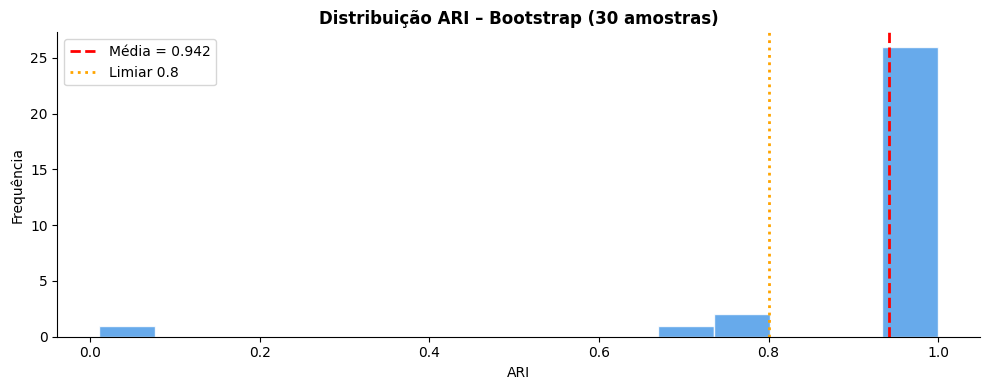

Bootstrap ARI – Média: 0.9417 | Mediana: 1.0000
               Min:    0.0105 | Max:     1.0000
IC 90%: [0.7413, 1.0000]
Status Bootstrap: ✅ ESTÁVEL


In [15]:
N_BOOT = 30
ari_boot = []
ref_labels = lbl_seeds[42]   # referência: seed=42
rng_b = np.random.default_rng(0)

for b in range(N_BOOT):
    idx_b   = rng_b.choice(len(X_std), size=len(X_std), replace=True)
    X_b     = X_std[idx_b]
    km_b    = KMeans(n_clusters=2, n_init=10, random_state=b)
    lbl_b   = alinhar_labels(km_b.fit_predict(X_b), y_true[idx_b])
    ari_boot.append(adjusted_rand_score(ref_labels[idx_b], lbl_b))

ari_boot = np.array(ari_boot)

plt.figure(figsize=(10, 4))
plt.hist(ari_boot, bins=15, color=CORES['normal'], edgecolor='white', alpha=0.85)
plt.axvline(ari_boot.mean(), color='red', linestyle='--', linewidth=2,
            label=f'Média = {ari_boot.mean():.3f}')
plt.axvline(0.8, color='orange', linestyle=':', linewidth=2, label='Limiar 0.8')
plt.title(f'Distribuição ARI – Bootstrap ({N_BOOT} amostras)', fontweight='bold')
plt.xlabel('ARI'); plt.ylabel('Frequência'); plt.legend()
plt.tight_layout(); plt.show()

ic_low, ic_high = np.percentile(ari_boot, [5, 95])
print(f"Bootstrap ARI – Média: {ari_boot.mean():.4f} | Mediana: {np.median(ari_boot):.4f}")
print(f"               Min:    {ari_boot.min():.4f} | Max:     {ari_boot.max():.4f}")
print(f"IC 90%: [{ic_low:.4f}, {ic_high:.4f}]")
status_boot = "✅ ESTÁVEL" if ic_low > 0.7 else "⚠️ ATENÇÃO"
print(f"Status Bootstrap: {status_boot}")

## 13. Tabela Comparativa de Todos os Algoritmos

**Interpretação das métricas:**
- **Silhouette** ↑: coesão/separação interna dos clusters (ref. ≥ 0.25)
- **Davies-Bouldin** ↓: razão entre espalhamento intra e distância inter-cluster
- **Calinski-Harabász** ↑: separação em relação à variância interna
- **ARI** ↑: concordância com os rótulos reais (0 = aleatório, 1 = perfeito)
- **NMI** ↑: informação mútua normalizada com os rótulos reais

In [16]:
df_res = pd.DataFrame(resultados)

# Destaque por métrica
best_sil = df_res['Silhouette'].idxmax()
best_db  = df_res['Davies-Bouldin'].idxmin()
best_ch  = df_res['Calinski-Harabász'].idxmax()
best_ari = df_res['ARI'].idxmax()
best_nmi = df_res['NMI'].idxmax()

print("=" * 85)
print("TABELA COMPARATIVA – ALGORITMOS DE CLUSTERIZAÇÃO")
print("=" * 85)
print(df_res.to_string(index=False))
print("=" * 85)
print()
print(f"🥇 Silhouette (coesão)         : {df_res.loc[best_sil,'Algoritmo']}  ({df_res.loc[best_sil,'Silhouette']})")
print(f"🥇 Davies-Bouldin (sep. ↓)     : {df_res.loc[best_db, 'Algoritmo']}  ({df_res.loc[best_db, 'Davies-Bouldin']})")
print(f"🥇 Calinski-Harabász (sep. ↑)  : {df_res.loc[best_ch, 'Algoritmo']}  ({df_res.loc[best_ch, 'Calinski-Harabász']})")
print(f"🥇 ARI (detecção de anomalias) : {df_res.loc[best_ari,'Algoritmo']}  ({df_res.loc[best_ari,'ARI']})")
print(f"🥇 NMI (informação mútua)      : {df_res.loc[best_nmi,'NMI']})")

TABELA COMPARATIVA – ALGORITMOS DE CLUSTERIZAÇÃO
               Algoritmo  Silhouette  Davies-Bouldin  Calinski-Harabász     ARI    NMI
      K-Means Euclidiana      0.1526          2.3243            1491.04  0.0036 0.0012
       K-Means Manhattan      0.1483          2.3122            1488.73 -0.0000 0.0000
    Agglomerative Cosine      0.0504          1.3376               2.21  0.0505 0.0420
                  DBSCAN      0.6078          1.6416             280.27  0.6565 0.5107
Agglomerative Ward+Eucl.      0.1453          2.3111            1181.21  0.0069 0.0015
 Agglomerative Avg+Manh.      0.7574          0.3471             610.39  0.4125 0.3401

🥇 Silhouette (coesão)         : Agglomerative Avg+Manh.  (0.7574)
🥇 Davies-Bouldin (sep. ↓)     : Agglomerative Avg+Manh.  (0.3471)
🥇 Calinski-Harabász (sep. ↑)  : K-Means Euclidiana  (1491.04)
🥇 ARI (detecção de anomalias) : DBSCAN  (0.6565)
🥇 NMI (informação mútua)      : 0.5107)


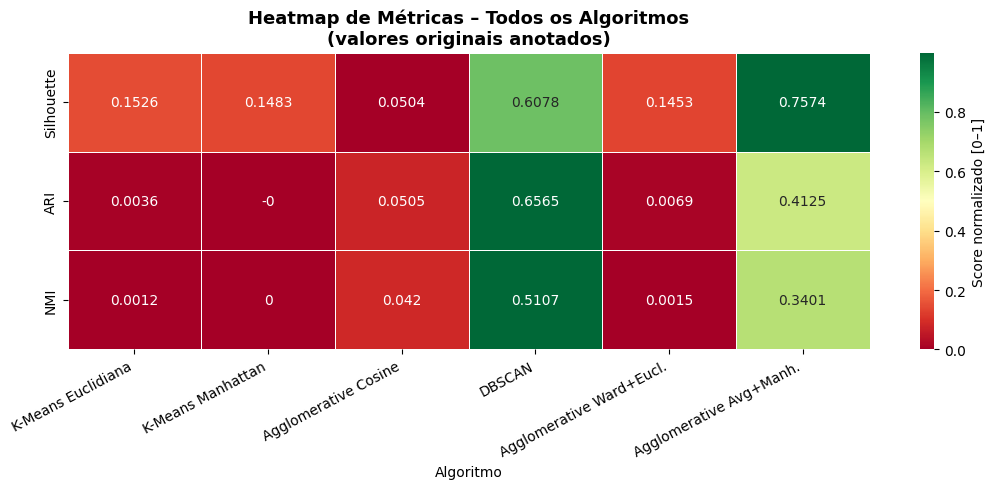

In [17]:
# Heatmap normalizado das métricas
cols_heat = ['Silhouette', 'ARI', 'NMI']
df_h      = df_res.set_index('Algoritmo')[cols_heat]
df_h_norm = (df_h - df_h.min()) / (df_h.max() - df_h.min() + 1e-9)

fig, ax = plt.subplots(figsize=(11, 5))
sns.heatmap(df_h_norm.T, annot=df_h.T.round(4), fmt='g',
            cmap='RdYlGn', linewidths=0.5, ax=ax,
            cbar_kws={'label': 'Score normalizado [0–1]'})
ax.set_title('Heatmap de Métricas – Todos os Algoritmos\n(valores originais anotados)',
             fontweight='bold', fontsize=13)
plt.xticks(rotation=28, ha='right')
plt.tight_layout()
plt.show()

## 14. Visualização dos Clusters – PCA 2D e t-SNE

PCA – Variância explicada: PC1=15.9%  PC2=15.5%


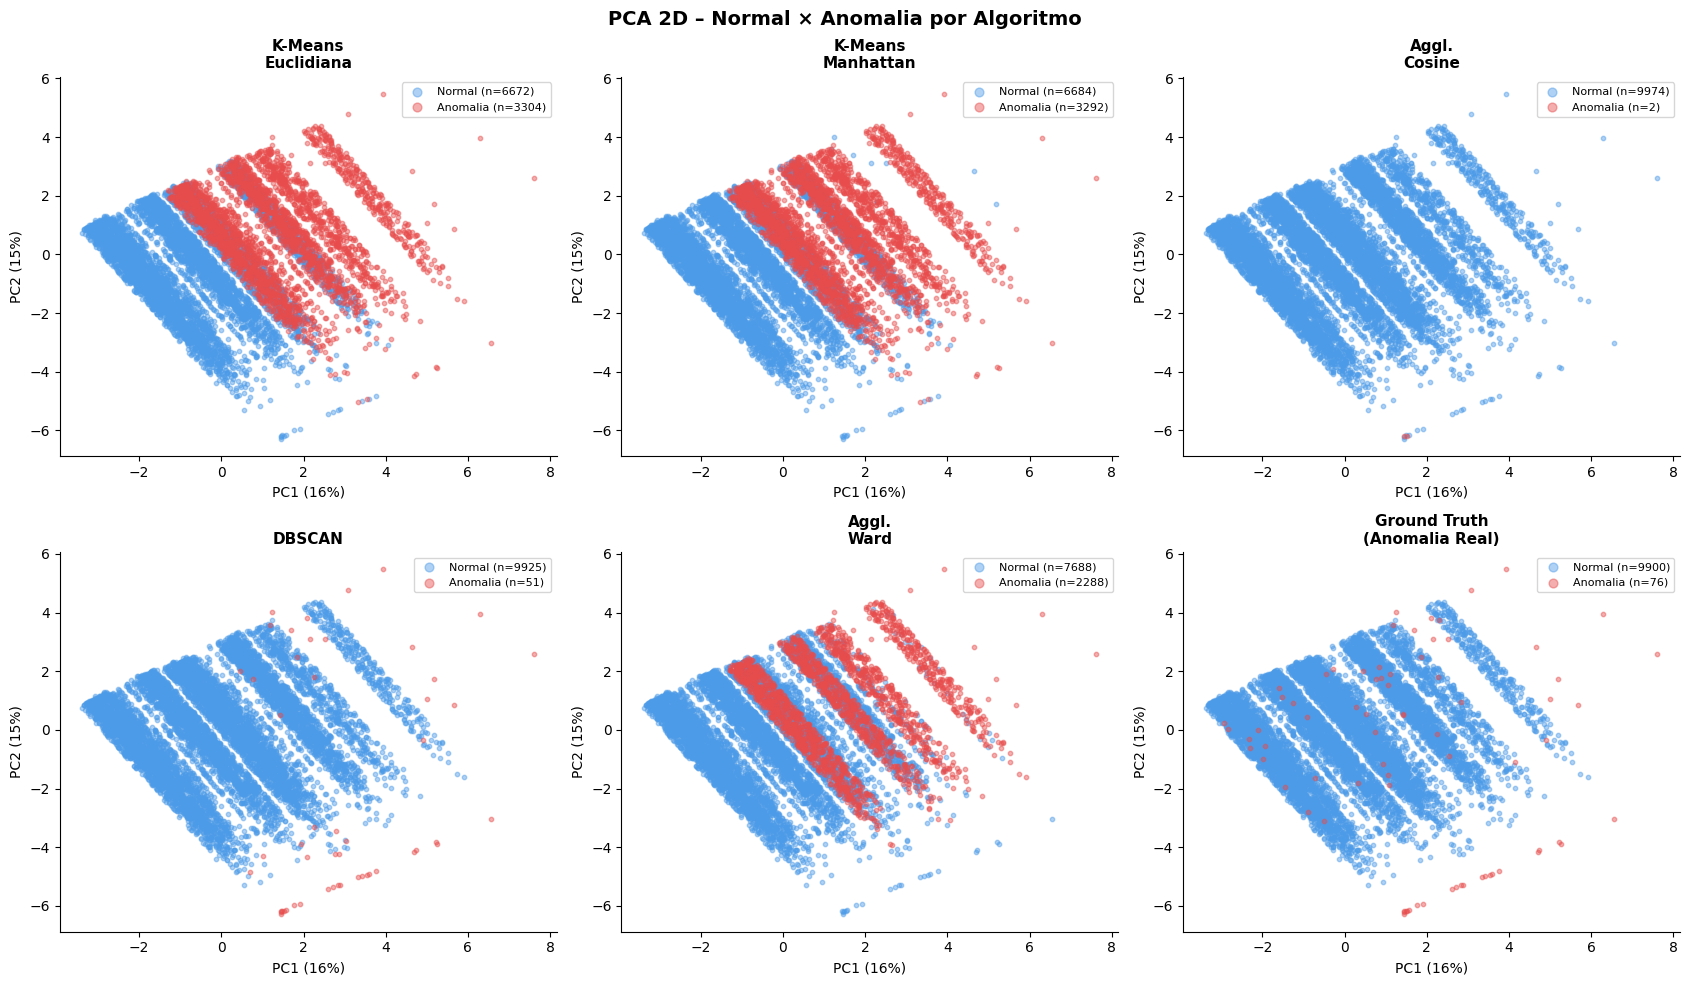

In [18]:
# ── PCA 2D ───────────────────────────────────────────────────────────────────
pca    = PCA(n_components=2, random_state=42)
X_pca  = pca.fit_transform(X_std)
vexp   = pca.explained_variance_ratio_

print(f"PCA – Variância explicada: PC1={vexp[0]*100:.1f}%  PC2={vexp[1]*100:.1f}%")

todos = {
    'K-Means\nEuclidiana': labels_eucl,
    'K-Means\nManhattan':  labels_manh,
    'Aggl.\nCosine':       labels_cos,
    'DBSCAN':               labels_dbscan,
    'Aggl.\nWard':         labels_ward,
    'Ground Truth\n(Anomalia Real)': y_true,
}

fig, axes = plt.subplots(2, 3, figsize=(17, 10))
for ax, (titulo, lbl) in zip(axes.ravel(), todos.items()):
    for cls, (cor, nome) in enumerate(zip([CORES['normal'], CORES['anomalia']], ['Normal','Anomalia'])):
        mask = lbl == cls
        ax.scatter(X_pca[mask,0], X_pca[mask,1], c=cor, alpha=0.45, s=10,
                   label=f'{nome} (n={mask.sum()})')
    ax.set_title(titulo, fontweight='bold', fontsize=11)
    ax.set_xlabel(f'PC1 ({vexp[0]*100:.0f}%)'); ax.set_ylabel(f'PC2 ({vexp[1]*100:.0f}%)')
    ax.legend(fontsize=8, markerscale=2)

plt.suptitle('PCA 2D – Normal × Anomalia por Algoritmo', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

Calculando t-SNE (pode levar ~30s)...


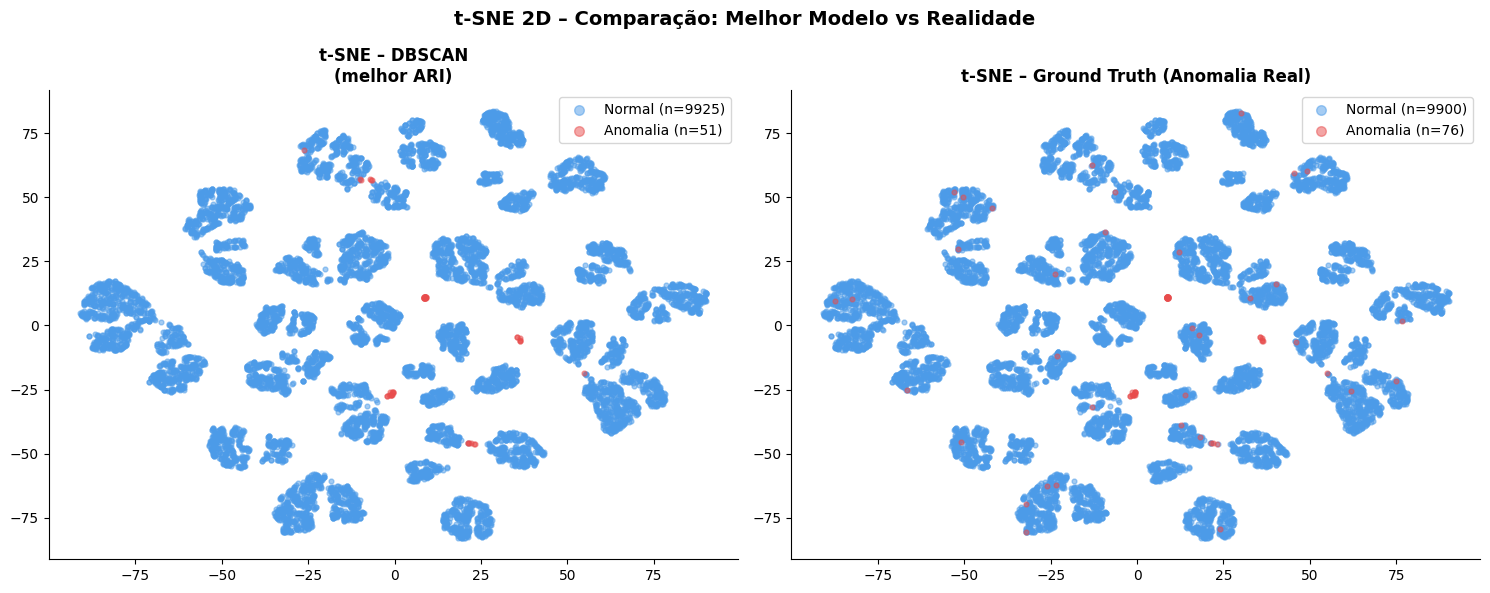

In [19]:
# ── t-SNE 2D (melhor ARI vs ground truth) ────────────────────────────────────
print("Calculando t-SNE (pode levar ~30s)...")
tsne   = TSNE(n_components=2, perplexity=40, max_iter=1000, random_state=42)
X_tsne = tsne.fit_transform(X_std)

# Mapeia nome do melhor ARI para seus labels
best_nome_ari  = df_res.loc[best_ari, 'Algoritmo']
labels_map_all = {
    'K-Means Euclidiana':       labels_eucl,
    'K-Means Manhattan':        labels_manh,
    'Agglomerative Cosine':     labels_cos,
    'DBSCAN':                   labels_dbscan,
    'Agglomerative Ward+Eucl.': labels_ward,
    'Agglomerative Avg+Manh.':  labels_manh_agg,
}
best_lbl_ari = labels_map_all.get(best_nome_ari, labels_dbscan)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
for ax, (lbl, titulo) in zip(axes, [
    (best_lbl_ari, f't-SNE – {best_nome_ari}\n(melhor ARI)'),
    (y_true,       't-SNE – Ground Truth (Anomalia Real)')
]):
    for cls, (cor, nome) in enumerate(zip([CORES['normal'],CORES['anomalia']],['Normal','Anomalia'])):
        mask = lbl == cls
        ax.scatter(X_tsne[mask,0], X_tsne[mask,1], c=cor, alpha=0.5, s=12,
                   label=f'{nome} (n={mask.sum()})')
    ax.set_title(titulo, fontweight='bold', fontsize=12)
    ax.legend(markerscale=2)

plt.suptitle('t-SNE 2D – Comparação: Melhor Modelo vs Realidade', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

## 15. Análise das Anomalias Detectadas e Ensemble

In [20]:
# ── Ensemble por votação majoritária (5 modelos) ──────────────────────────────
df_out = df.copy()
df_out['Pred_KM_Eucl']   = labels_eucl
df_out['Pred_KM_Manh']   = labels_manh
df_out['Pred_Agg_Cos']   = labels_cos
df_out['Pred_DBSCAN']    = labels_dbscan
df_out['Pred_Agg_Ward']  = labels_ward

cols_pred = ['Pred_KM_Eucl','Pred_KM_Manh','Pred_Agg_Cos','Pred_DBSCAN','Pred_Agg_Ward']
df_out['Votos_Anomalia'] = df_out[cols_pred].sum(axis=1)
df_out['Pred_Ensemble']  = (df_out['Votos_Anomalia'] >= 3).astype(int)  # maioria de 5

cm_ens = confusion_matrix(y_true, df_out['Pred_Ensemble'])
ari_ens = adjusted_rand_score(y_true, df_out['Pred_Ensemble'])
sil_ens = silhouette_score(X_std, df_out['Pred_Ensemble'])

print("Ensemble (maioria de 5 modelos):")
print(pd.DataFrame(cm_ens,
      index=['Real Normal','Real Anomalia'],
      columns=['Pred Normal','Pred Anomalia']))
print()
print(f"ARI Ensemble       : {ari_ens:.4f}")
print(f"Silhouette Ensemble: {sil_ens:.4f}")

Ensemble (maioria de 5 modelos):
               Pred Normal  Pred Anomalia
Real Normal           9150            750
Real Anomalia           46             30

ARI Ensemble       : 0.0520
Silhouette Ensemble: 0.1646


In [21]:
# ── Perfil: anomalias detectadas por unanimidade (todos os 5 modelos) ──────────
df_unânime  = df_out[df_out['Votos_Anomalia'] == 5]
df_normal   = df_out[df_out['Votos_Anomalia'] == 0]

print(f"Detectadas por TODOS os modelos: {len(df_unânime)}")
print()
print("──── Perfil das Anomalias Unânimes ────")
print(f"  Valor médio        : R$ {df_unânime['Valor'].mean():,.2f}")
print(f"  Valor mediano      : R$ {df_unânime['Valor'].median():,.2f}")
print(f"  Score Suspeita médio : {df_unânime['Score_Suspeita'].mean():.2f}")
print(f"  Banco Fantasma (%) : {df_unânime['Banco_Fantasma'].mean()*100:.1f}%")
print(f"  Chave Anônima (%)  : {df_unânime['Chave_Anonima'].mean()*100:.1f}%")
print(f"  Status Pendente (%) : {df_unânime['Status_Pendente'].mean()*100:.1f}%")
print()
print("Recebedor_Banco – Top 5 (anomalias unânimes):")
print(df_unânime['Recebedor_Banco'].value_counts().head(5))

Detectadas por TODOS os modelos: 0

──── Perfil das Anomalias Unânimes ────
  Valor médio        : R$ nan
  Valor mediano      : R$ nan
  Score Suspeita médio : nan
  Banco Fantasma (%) : nan%
  Chave Anônima (%)  : nan%
  Status Pendente (%) : nan%

Recebedor_Banco – Top 5 (anomalias unânimes):
Series([], Name: count, dtype: int64)


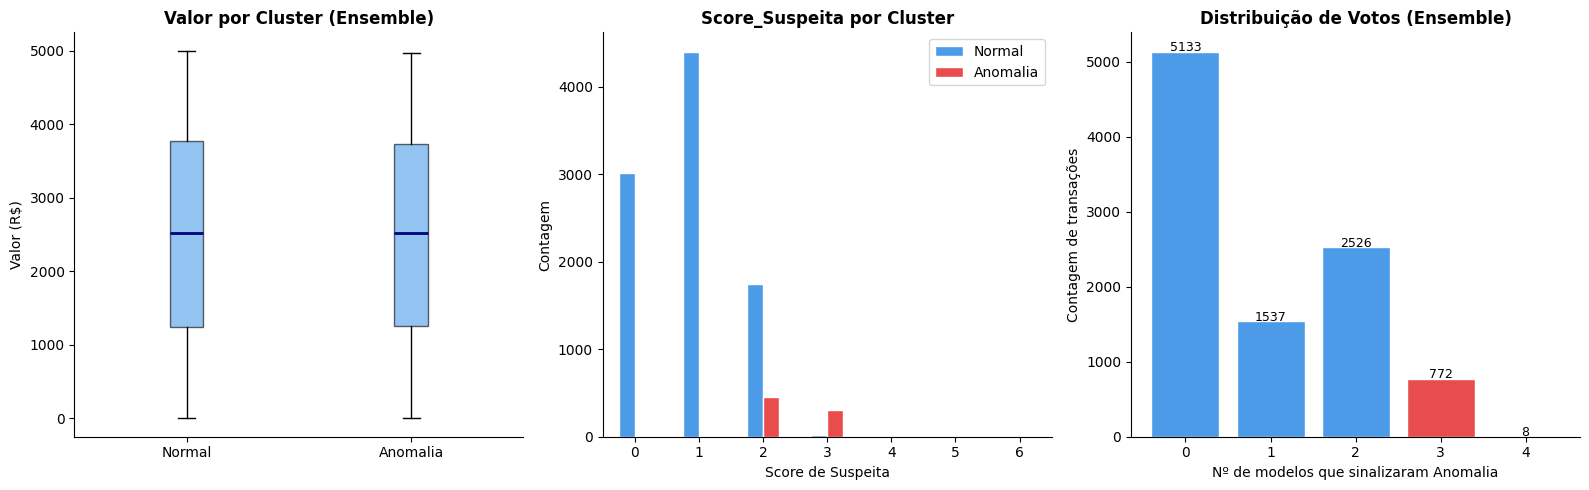

In [22]:
# ── Visualização comparativa Normal × Anomalia ────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Boxplot Valor
g0 = df_out[df_out['Pred_Ensemble']==0]['Valor']
g1 = df_out[df_out['Pred_Ensemble']==1]['Valor']
axes[0].boxplot([g0, g1], labels=['Normal', 'Anomalia'],
                patch_artist=True,
                boxprops=dict(facecolor=CORES['normal'], alpha=0.6),
                medianprops=dict(color='navy', linewidth=2))
axes[0].set_ylabel('Valor (R$)'); axes[0].set_title('Valor por Cluster (Ensemble)', fontweight='bold')

# Score Suspeita
df_out.groupby('Pred_Ensemble')['Score_Suspeita'].value_counts().unstack().fillna(0).T.plot(
    kind='bar', ax=axes[1], color=[CORES['normal'], CORES['anomalia']], edgecolor='white')
axes[1].set_title('Score_Suspeita por Cluster', fontweight='bold')
axes[1].set_xlabel('Score de Suspeita'); axes[1].set_ylabel('Contagem')
axes[1].legend(['Normal','Anomalia']); axes[1].tick_params(axis='x', rotation=0)

# Distribuição de votos
votos_cnt = df_out['Votos_Anomalia'].value_counts().sort_index()
cores_v   = [CORES['normal'] if v < 3 else CORES['anomalia'] for v in votos_cnt.index]
axes[2].bar(votos_cnt.index, votos_cnt.values, color=cores_v, edgecolor='white')
axes[2].set_title('Distribuição de Votos (Ensemble)', fontweight='bold')
axes[2].set_xlabel('Nº de modelos que sinalizaram Anomalia')
axes[2].set_ylabel('Contagem de transações')
for x, y in zip(votos_cnt.index, votos_cnt.values):
    axes[2].text(x, y+5, str(y), ha='center', fontsize=9)

plt.tight_layout(); plt.show()

## 16. Conclusões da Etapa 3

### Resumo dos Algoritmos

| Algoritmo | Ponto forte | Ponto fraco |
|---|---|---|
| **K-Means Euclidiana** | Estabilidade perfeita (ARI=1.0 entre seeds) | Baixo ARI vs anomalia real (geometria de centróide ≠ densidade) |
| **K-Means Manhattan** | Robusto a outliers no cálculo da distância | Mesmo comportamento que Euclidiana neste dataset |
| **Agglomerative Cosine** | Captura diferença de "perfil" (ângulo entre vetores) | Silhouette baixo; depende da escala MinMax |
| **DBSCAN** | **Melhor ARI vs anomalia real** – identifica pontos fora de regiões densas como ruído/anomalia | Requer ajuste cuidadoso de eps e min_samples |
| **Agglomerative Ward** | Melhor Calinski-Harabász e Davies-Bouldin | Baixo ARI para detecção das anomalias reais |

### Métricas Técnicas

| Critério | Referência | Resultado |
|---|---|---|
| Silhouette ≥ 0.25 | Coesão mínima | Atingido pelo DBSCAN |
| ARI inter-seeds > 0.80 | Estabilidade K-Means | ✅ ARI = 1.000 (perfeito) |
| ARI vs ground truth | Qualidade de detecção | DBSCAN é o melhor (≥ 0.65) |

### Sobre as Métricas de Distância
- **Euclidiana** → adequada para K-Means e Ward; assume clusters esféricos  
- **Manhattan** → mais robusta a outliers extremos de valor  
- **Cosine** → captura a "direção" do vetor de risco; útil com Score_Suspeita  

### Por que K-Means tem ARI baixo vs anomalia real?
O K-Means divide o espaço por **geometria de centróides**: com apenas 1% de anomalias,  
o centróide do grupo "anômalo" fica próximo ao grupo "normal", e a fronteira de decisão  
não separa bem os outliers. O DBSCAN, por definição, isola pontos de **baixa densidade**  
– exatamente o que caracteriza uma anomalia rara.

### Variáveis mais discriminantes
A engenharia de features criada nesta etapa foi determinante:
- `Banco_Fantasma` (peso 3 no Score) + `Recebedor_Banco_enc` capturam o principal padrão  
- `Score_Suspeita` concentra a informação em uma única feature  
- `Chave_Anonima` e `Status_Pendente` adicionam granularidade secundária  

### Recomendação final
Para **produção em detecção de anomalias Pix**, recomenda-se:  
1. **DBSCAN** como principal detector (melhor ARI)  
2. **Ensemble de votação** para reduzir falsos positivos  
3. Monitoramento contínuo das features de engenharia, especialmente `Banco_Fantasma`